# Import and Data filtering

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("data/benchmark_mids_cs.csv")

data.head()

,Unnamed: 0,time_stamp,isin,price,yield,country_iso,mat_cat,source,remaining_maturity,dv01
0,0,2015-01-07 17:44:00+00:00,DE0001102366,104.835,0.4835,DE,10,ref,9.601643,0.000961
1,1,2015-01-07 17:43:00+00:00,DE0001102366,104.835,0.4835,DE,10,ref,9.601643,0.000961
2,2,2015-01-07 17:42:00+00:00,DE0001102366,104.835,0.4835,DE,10,ref,9.601643,0.000961
3,3,2015-01-07 17:41:00+00:00,DE0001102366,104.835,0.4835,DE,10,ref,9.601643,0.000961
4,4,2015-01-07 17:40:00+00:00,DE0001102366,104.835,0.4835,DE,10,ref,9.601643,0.000961


# Estimation des return

In [134]:
# on def ret_t = Pt-Pt-1/Pt-1 + Yieldt−1​×Δt​/T
# on suppose Δt​/T = 1/252  


data = data.sort_values(['isin', 'time_stamp'])
#data['delta_yield'] = data.groupby('isin')['yield'].diff()
data['price_return'] = data.groupby('isin')['price'].apply(lambda x: x.pct_change())
data['daily_return'] = data['price_return'] + data['yield'].shift(1)*(1/252)  # daily approx


C:\Users\hugoj\AppData\Local\Temp\ipykernel_15464\1410165640.py:7: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  data['price_return'] = data.groupby('isin')['price'].apply(lambda x: x.pct_change())


In [135]:
df_FR = data[data["country_iso"]=="FR"]
df_DE = data[data["country_iso"]=="DE"]
df_IT = data[data["country_iso"]=="IT"]

val = "daily_return"
df_FR = df_FR.pivot(index="time_stamp", values=val, columns="mat_cat")
df_DE = df_DE.pivot(index="time_stamp", values=val, columns="mat_cat")
df_IT = df_IT.pivot(index="time_stamp", values=val, columns="mat_cat")

df_FR.index = pd.to_datetime(df_FR.index)
df_DE.index = pd.to_datetime(df_DE.index)
df_IT.index = pd.to_datetime(df_IT.index)


In [136]:
df_FR.head()

mat_cat,2,5,10,15,30
time_stamp,,,,,
2015-01-01 06:45:00+00:00,NaN,NaN,NaN,NaN,NaN
2015-01-01 06:46:00+00:00,NaN,NaN,NaN,0.005538,NaN
2015-01-01 06:47:00+00:00,NaN,NaN,NaN,0.005538,NaN
2015-01-01 06:48:00+00:00,NaN,NaN,NaN,0.005538,NaN
2015-01-01 06:49:00+00:00,NaN,NaN,NaN,0.005538,NaN


In [137]:
df_FR = df_FR.resample('1D').last()
df_DE = df_DE.resample('1D').last()
df_IT = df_IT.resample('1D').last()

df_FR

mat_cat,2,5,10,15,30
time_stamp,,,,,
2015-01-01 00:00:00+00:00,NaN,NaN,NaN,0.005538,NaN
2015-01-02 00:00:00+00:00,NaN,NaN,NaN,0.005540,NaN
2015-01-03 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN
2015-01-04 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN
2015-01-05 00:00:00+00:00,NaN,NaN,NaN,0.005377,NaN
...,...,...,...,...,...
2025-10-17 00:00:00+00:00,0.008445,0.010565,0.013365,0.014954,0.016725
2025-10-18 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN
2025-10-19 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN


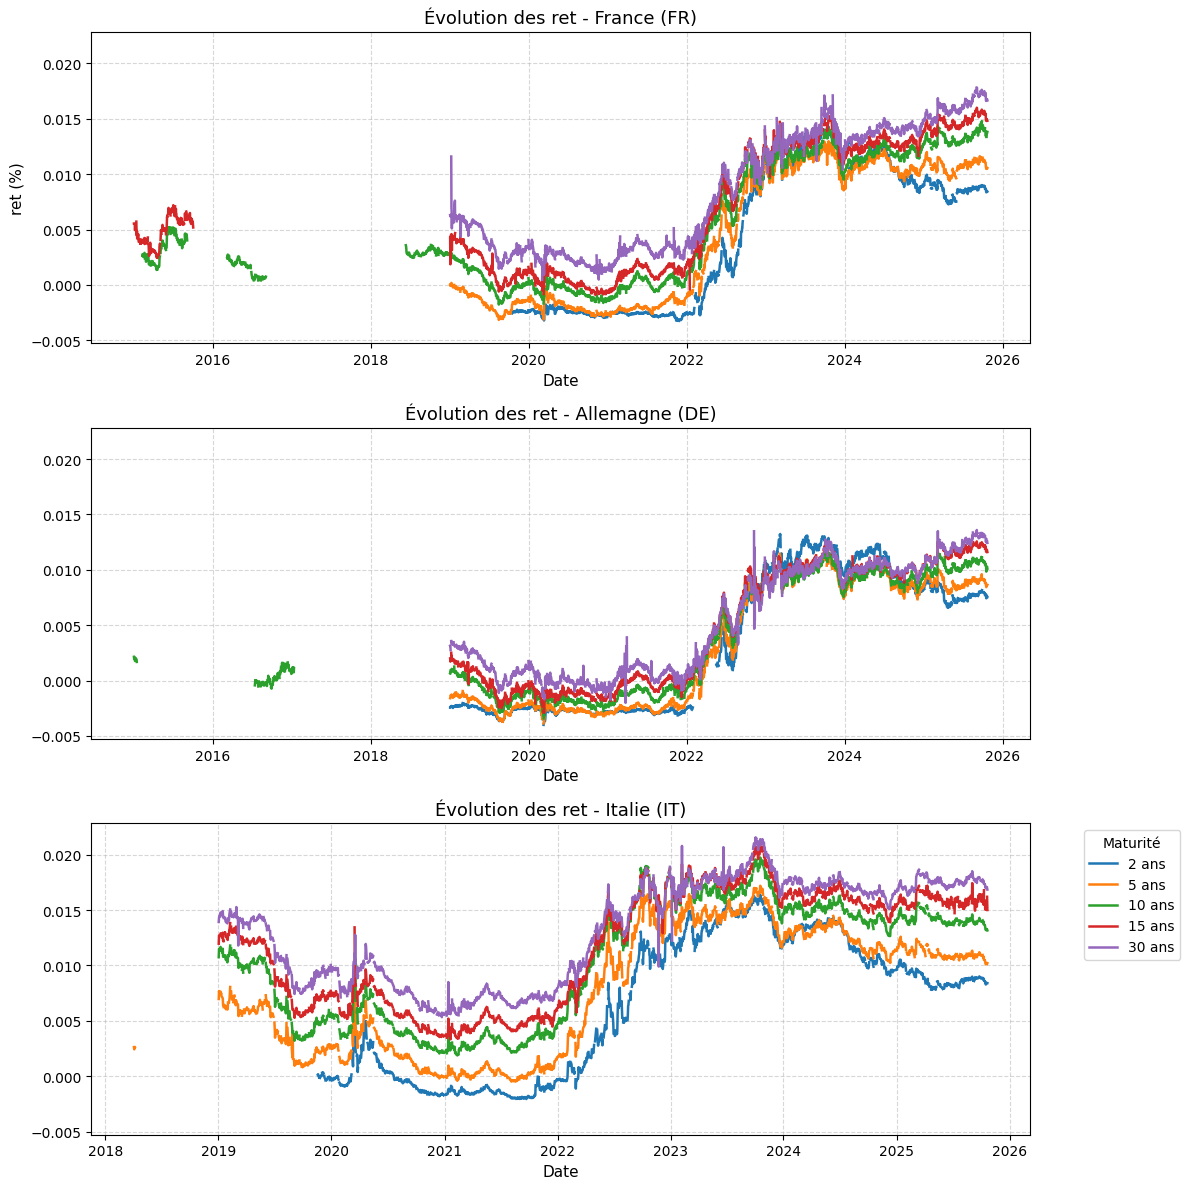

In [138]:
import matplotlib.pyplot as plt

# Figure globale : 3 sous-graphiques côte à côte
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharey=True)

# Dictionnaire pour simplifier la boucle
dfs = {
    "France (FR)": df_FR,
    "Allemagne (DE)": df_DE,
    "Italie (IT)": df_IT
}

# Boucle sur les pays
for ax, (country, df) in zip(axes, dfs.items()):
    # Tracé
    for col in df.columns:
        ax.plot(df.index, df[col], label=f"{col} ans", linewidth=1.8)
    
    # Titres et labels
    ax.set_title(f"Évolution des ret - {country}", fontsize=13)
    ax.set_xlabel("Date", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.5)
    
# Label vertical partagé
axes[0].set_ylabel("ret (%)", fontsize=11)

# Légende commune
axes[-1].legend(title="Maturité", bbox_to_anchor=(1.05, 1), loc='upper left')

# Mise en page
plt.tight_layout()
plt.show()


# Creation d'UN portfolio

In [139]:

class Portfolio():
    def __init__(self, data_dict,date, benchmark = "ew", long_only = False, lamb = 1):
        """
        data_dict : dict
            Dictionnaire de DataFrames (par ex. {'FR': df_FR, 'DE': df_DE, 'IT': df_IT})
            Chaque DataFrame a un DatetimeIndex et des colonnes = maturités (mat_cat)
        
        date : datetime
            On précise la date du portfeuille 

        benchmark : string
            On précise ce qu'est notre benchmark si contrainte de distance au bm
            Pas utilisé pour le moment
            ew = equally weigted
        """

        self.data = data_dict
        self.date = date
        self.benchmark = benchmark
        self.returns = None
        self.mean_returns = None
        self.cov_matrix = None
        self.weights = None
        self.long_only = long_only
        self.lamb = lamb
        self.benchmark_weights = None


    def get_returns_until(self):
        """
        Calcule les rendements journaliers jusqu’à la date donnée (incluse !!) 
        à modifier pour traiter plutôt avec les DV01
        """

        date_t = pd.to_datetime(self.date)
        all_returns = []

        for country, df in self.data.items():
            # Garder uniquement les observations avant t compris
            df_t = df[df.index <= date_t]
            
            # Calcul du rendement journalier à modif 
            rets = df_t.dropna()
            rets.columns = [f"{country}_{c}" for c in rets.columns]
            all_returns.append(rets)

        # Fusionner toutes les séries
        self.returns = pd.concat(all_returns, axis=1).dropna()
        
    
    def estimate_returns(self):
        """
        Estime le vecteur returns, avec moyenne pour le moment
        """

        self.mean_returns = self.returns.mean()
        
    
    def estimate_cov_matrix(self):
        """
        Estime la matrice de covariance, simple pour le moment
        """
        self.cov_matrix = self.cov_matrix = self.returns.cov()
        
    

    def simple_marokwitz(self, normalize = False):
        """
        Markowitz simple, sans contrainte longue and short V = wTR - lambda*wTsigmaw 
        a faire plus tard : rajouter contraintes, faire optimisation à partir de seuil 
        de return ou variance

        Le long_only est à modifier, il faut faire une optimization sur w >= 0 
        """
        mu = np.array(self.mean_returns)
        Sigma = np.array(self.cov_matrix) + 0.001*np.diag(np.ones(self.cov_matrix.shape[0]))
        
        # Poids non normalisés
        w = np.linalg.inv(2 * self.lamb * Sigma) @ mu

        if self.long_only:
            w = np.maximum(w, 0)   # coupe les négatifs
            w /= w.sum()           # on normalize toujours les long_only 
        
        if normalize:
            w /= w.sum()
            
        self.weights = pd.DataFrame(w, index=self.mean_returns.index, columns=[self.date])
    
    def benchmark_w(self):
        if self.benchmark == "ew":
            self.benchmark_weights = pd.DataFrame(np.ones(self.mean_returns.shape)/self.mean_returns.shape, index=self.mean_returns.index, columns=[self.date])
        

    def process(self):
        """
        Process entier pour obtenier les poids finaux
        """
        self.get_returns_until()
        self.estimate_returns()
        self.estimate_cov_matrix()
        self.simple_marokwitz()
        self.benchmark_w()
        return self.weights

data_dict = {
    'FR': df_FR,
    'DE': df_DE,
    'IT': df_IT
}
date = "2020-01-01 00:00:00+00:00"
pf = Portfolio(data_dict,date)
w = pf.process()
print(w)

       2020-01-01 00:00:00+00:00
FR_2                   -1.205687
FR_5                   -0.726352
FR_10                   0.004892
FR_15                   0.535023
FR_30                   1.580535
DE_2                   -1.263382
DE_5                   -1.100689
DE_10                  -0.597917
DE_15                  -0.329499
DE_30                   0.461420
IT_2                   -0.028116
IT_5                    1.196501
IT_10                   2.555864
IT_15                   3.603262
IT_30                   4.715126


# Creation du time serie pf

In [204]:
class TimeSeriesPortfolio():
    def __init__(self, data_dict, start_date, end_date, rebalance_freq='1D', long_only=False, lamb=1,benchamark = "ew"):
        """
        data_dict : dict
            Dictionnaire de DataFrames par pays {'FR': df_FR, ...}
            Chaque DataFrame a un DatetimeIndex et des colonnes = maturités (mat_cat)
        start_date, end_date : str/datetime
            Dates de début et fin du backtest
        rebalance_freq : str
            Pandas offset alias ('1D', '1W', '1M', ...)
            On a fait une approxi ici, à modif dans le futur
        long_only : bool
            Long only ou pas
        lamb : float
            Coefficient de risque pour Markowitz
        """
        self.data_dict = data_dict
        self.start_date = pd.to_datetime(start_date)
        self.end_date = pd.to_datetime(end_date)
        self.rebalance_freq = rebalance_freq
        self.long_only = long_only
        self.lamb = lamb
        self.benchmark = benchamark
        self.rebalance_dates = None
        self.all_dates = None
        self.weights_history = pd.DataFrame()
        self.portfolio_returns = pd.Series(dtype=float)
        self.benchmark_returns = pd.Series(dtype=float)
        self.metrics = {}


    def freq_to_pd_freq(self):
        """
        Convertit ton format (ex: '1D','5D','1W','1M') en fréquence utilisable par pd.date_range.
        On gère 'D','B','W','M' ; 'B' (business day) pourrait être utile pour plusieurs cas.
        """
        f = self.rebalance_freq.upper()
        # accepter '1D','5D','1W','1M','1B' etc.
        # si l'utilisateur a mis juste 'D' ou 'W' on le corrige
        if f.endswith('D') or f.endswith('B') or f.endswith('W') or f.endswith('M'):
            return f
        # fallback
        return '1D'


    def generate_rebalance_dates(self):
        """
        Construis self.all_dates (index trading union) puis génère self.rebalance_dates en
        mappant une grille temporelle (pd.date_range) sur le prochain jour de marché disponible.
        """
        # union propre des index (DatetimeIndex)
        all_dates = None
        for df in self.data_dict.values():
            if all_dates is None:
                all_dates = df.index
            else:
                all_dates = all_dates.union(df.index)

        # filtrer la période demandée
        all_dates = all_dates[(all_dates >= self.start_date) & (all_dates <= self.end_date)]
        all_dates = all_dates.sort_values()
        self.all_dates = all_dates

        if len(all_dates) == 0:
            raise ValueError("Aucune date de marché disponible dans la période fournie.")

        # construire une grille de cibles selon la freq demandée
        # .normalize() on ignore l'heure
        pd_freq = self.freq_to_pd_freq()
        targets = pd.date_range(start=self.start_date.normalize(), end=self.end_date.normalize(), freq=pd_freq)

        # pour chaque target, trouver le premier jour de marché >= target
        reb_dates = []
        for tgt in targets:
            pos = all_dates.searchsorted(tgt)
            if pos < len(all_dates):
                d = all_dates[pos]
                # éviter les doublons (si plusieurs targets mappent sur le même jour)
                if (len(reb_dates) == 0) or (d != reb_dates[-1]):
                    # s'assurer que la date mappée est dans la fenêtre start/end
                    if d >= self.start_date and d <= self.end_date:
                        reb_dates.append(d)

        # s'assurer d'inclure la dernière date possible (utile si target n'atteint pas la fin)
        if all_dates[-1] not in reb_dates:
            reb_dates.append(all_dates[-1])

        self.rebalance_dates = pd.DatetimeIndex(reb_dates)
        return self.rebalance_dates, self.all_dates


    def generate_portfolios(self):
        """
        Génère poids à chaque date de rebalancement et calcule les rendements entre rebalancements.
        - On retourne self.weights_history (index = rebalance_dates)
        - self.portfolio_returns et self.benchmark_returns (index = dates de marché réelles utilisées pour les retours)
        """
        if self.rebalance_dates is None or self.all_dates is None:
            self.generate_rebalance_dates()

        pf_weights = []
        bm_weights = []
        pf_returns = []
        bm_returns = []
        returns_dates = []  # dates correspondantes à chaque rendement stocké

        # boucle sur chaque période [t, t_next_rebal] (on ignore le dernier rebal comme point de départ)
        for i, t in enumerate(self.rebalance_dates[:-1]):
            t_next_rebal = self.rebalance_dates[i + 1]

            # --- construire portefeuille à la date t ---
            pf = Portfolio(self.data_dict, t, long_only=self.long_only, lamb=self.lamb)
            w_df = pf.process()  
            pf_w = w_df.values.flatten()
            bm_w = pf.benchmark_weights.values.flatten()

            # stocker les poids
            pf_weights.append(pf_w)
            bm_weights.append(bm_w)

            # --- calculer les rendements pour chaque date de marché entre t (exclu) et t_next_rebal (inclu) ---
            mask = (self.all_dates > t) & (self.all_dates <= t_next_rebal)
            dates_in_period = self.all_dates[mask]

            for date_r in dates_in_period:
                # collecter les returns pour date_r
                all_returns = []
                for country, df in self.data_dict.items():
                    # récupérer la ligne pour la date_r si elle existe
                    if date_r in df.index:
                        row = df.loc[[date_r]].copy()
                        row.columns = [f"{country}_{c}" for c in row.columns]
                        all_returns.append(row)
                if all_returns:
                    r_next = pd.concat(all_returns, axis=1).reindex(columns=(w_df.index.map(lambda x: f"{x}" )), fill_value=0)
                    # IMPORTANT: on suppose que l'ordre des colonnes correspond à l'ordre des poids pf_w
                    # pour être sûr, on récupère r_vec en utilisant les mêmes index que w_df
                    r_vec = pd.concat(all_returns, axis=1).values.flatten()
                    # dot product
                    pf_ret = float(np.dot(r_vec, pf_w))
                    bm_ret = float(np.dot(r_vec, bm_w))
                else:
                    pf_ret = np.nan
                    bm_ret = np.nan

                pf_returns.append(pf_ret)
                bm_returns.append(bm_ret)
                returns_dates.append(date_r)

        # --- stockage historique ---
        # colonnes : nom des assets (ex: 'FR_2','FR_5',...) on les prend depuis w_df.index transformé si besoin
        asset_names = w_df.index if hasattr(w_df, 'index') else [f"a{i}" for i in range(len(pf_w))]
        self.weights_history = pd.DataFrame(pf_weights, index=self.rebalance_dates[:-1], columns=asset_names)

        # Series de retours indexées par les vraies dates de marché utilisées
        if len(returns_dates) > 0:
            self.portfolio_returns = pd.Series(pf_returns, index=pd.DatetimeIndex(returns_dates))
            self.benchmark_returns = pd.Series(bm_returns, index=pd.DatetimeIndex(returns_dates))
        else:
            self.portfolio_returns = pd.Series(dtype=float)
            self.benchmark_returns = pd.Series(dtype=float)

        # metrics simples
        if not self.portfolio_returns.empty:
            self.metrics = {
                'pf_cumulative_return': (1 + self.portfolio_returns.fillna(0)).cumprod(),
                'bm_cumulative_return': (1 + self.benchmark_returns.fillna(0)).cumprod(),
                'mean_return': self.portfolio_returns.mean(),
                'volatility': self.portfolio_returns.std(),
                'sharpe': (self.portfolio_returns.mean() / self.portfolio_returns.std()) if self.portfolio_returns.std() != 0 else np.nan
            }
        else:
            self.metrics = {}

        return self.weights_history, self.portfolio_returns, self.benchmark_returns


    # Plot weights ou performances

    def plot_weights(self):
        if self.weights_history.empty:
            raise ValueError("Aucune donnée de portefeuille. Lancez generate_portfolios()")
        
        plt.figure(figsize=(14, 6))
        
        # --- Plot stacked area pour visualiser les poids ---
        self.weights_history.plot(kind='area', stacked=True, ax=plt.gca(), alpha=0.7)
        
        plt.title("Historique des poids du portefeuille (stacked)")
        plt.xlabel("Date")
        plt.ylabel("Poids")
        plt.legend(loc='upper left', bbox_to_anchor=(1,1))
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        
        # --- Plot somme des poids (check si long-only normalisé) ---
        if self.long_only:
            plt.figure(figsize=(14,3))
            plt.plot(self.weights_history.sum(axis=1), marker='o', linestyle='-')
            plt.title("Somme des poids par date (doit être 1 si long-only)")
            plt.xlabel("Date")
            plt.ylabel("Somme des poids")
            plt.grid(True)
            plt.show()

    def plot_cumulative_return(self):
        if not self.metrics:
            raise ValueError("Aucune métrique calculée. Lancez generate_portfolios()")
        plt.figure(figsize=(12,6))
        self.metrics['pf_cumulative_return'].plot(label='Portfolio', color='blue')
        self.metrics['bm_cumulative_return'].plot(label='Benchmark', color='orange')
        
        plt.title("Performance cumulative : Portfolio vs Benchmark")
        plt.xlabel("Date")
        plt.ylabel("Cumulative Return")
        plt.legend(loc='best')
        plt.grid(True)
        plt.show()

In [211]:
data_dict = {
    'FR': df_FR,
    'DE': df_DE,
    'IT': df_IT
}

for country, df in data_dict.items():
    data_dict[country] = df.dropna(how='all')
start_date = "2020-01-01 00:00:00+00:00"
end_date = "2024-06-10 00:00:00+00:00"

tspf = TimeSeriesPortfolio(data_dict, start_date, end_date, rebalance_freq='1W', long_only=True)
_, _,_ = tspf.generate_portfolios()


In [212]:
tspf.metrics

{'pf_cumulative_return': 2020-01-07 00:00:00+00:00        1.006508
 2020-01-08 00:00:00+00:00        1.013188
 2020-01-09 00:00:00+00:00        1.019849
 2020-01-10 00:00:00+00:00        1.026429
 2020-01-13 00:00:00+00:00        1.033223
                                  ...     
 2024-06-04 00:00:00+00:00    33793.950087
 2024-06-05 00:00:00+00:00    34272.640465
 2024-06-06 00:00:00+00:00    34763.671799
 2024-06-07 00:00:00+00:00    35269.819056
 2024-06-10 00:00:00+00:00    35799.829619
 Length: 1146, dtype: float64,
 'bm_cumulative_return': 2020-01-07 00:00:00+00:00      1.001329
 2020-01-08 00:00:00+00:00      1.002818
 2020-01-09 00:00:00+00:00      1.004310
 2020-01-10 00:00:00+00:00      1.005799
 2020-01-13 00:00:00+00:00      1.007409
                                 ...    
 2024-06-04 00:00:00+00:00    680.436876
 2024-06-05 00:00:00+00:00    689.094289
 2024-06-06 00:00:00+00:00    697.961200
 2024-06-07 00:00:00+00:00    707.113110
 2024-06-10 00:00:00+00:00    716.6486

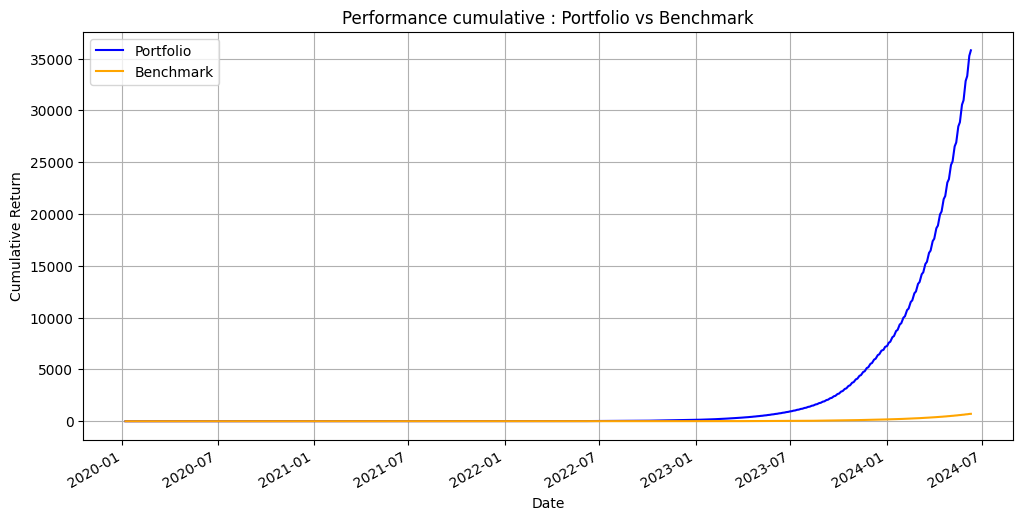

In [213]:
tspf.plot_cumulative_return()

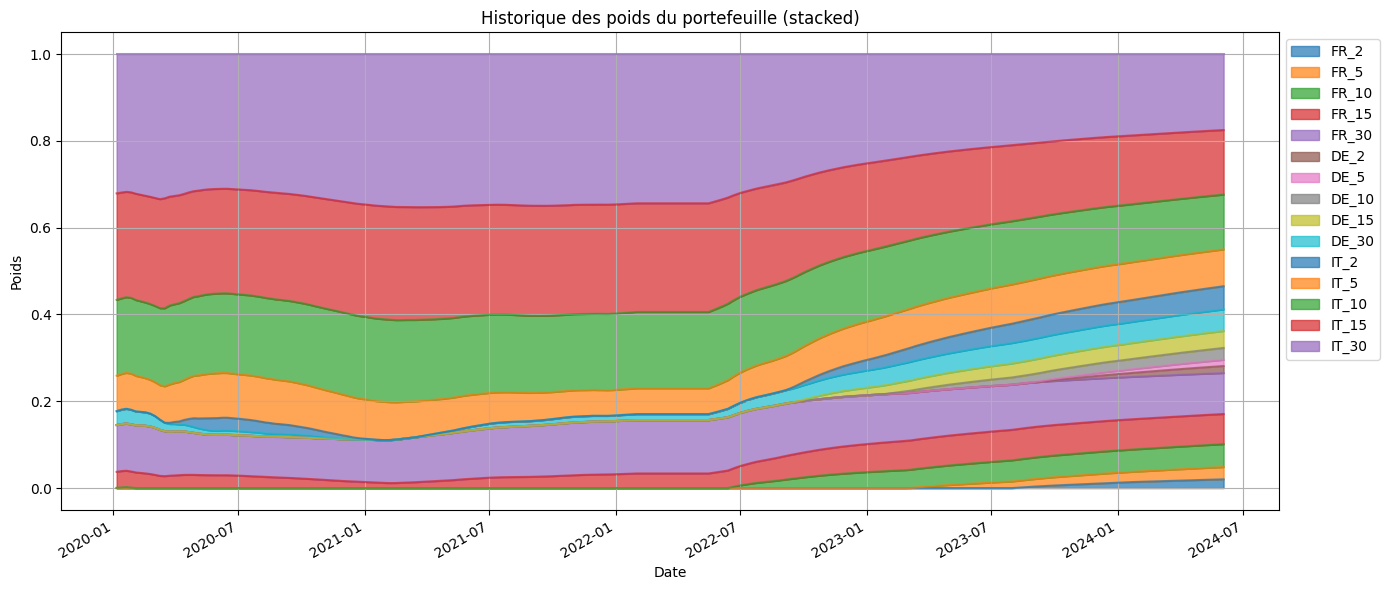

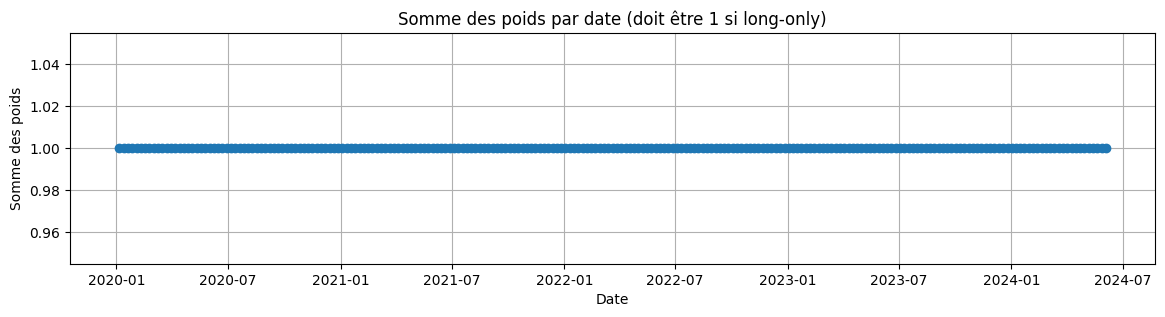

In [214]:
tspf.plot_weights()